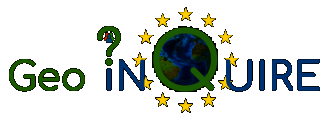

# Frequency-Magnitude Distribution — EFSM20

This notebook establishes a connection to the **European Fault-Source Model 2020 (EFSM20)** OGC web service **WFS** and lets the user retrieve and explore its data. Map visualization helps navigate it geographically and select items. With selected fault sources, the user can generate and plot earthquake Frequency-Magnitude distributions and compare the effects of parameter uncertainty. See https://seismofaults.eu/efsm20 for more details.

**Workflow:**

0. Install dependencies
1. Connect the WFS and list available layers
2. Download layer `efsm20_cf_top` and mapping
3. Select IDFS interactively
4. Calculate the Frequency-Magnitude Distributions and Plot FMD curves

**References**

Anderson, J. G., and Luco, J. E. (1983). Consequences of slip rate constraints on earthquake occurrence relations. Bulletin of the Seismological Society of America 73, 471–496. https://doi.org/10.1785/BSSA0730020471

Basili, R., Danciu, L., Beauval, C., Sesetyan, K., Vilanova, S. P., Adamia, S., et al. (2024). The European Fault-Source Model 2020 (EFSM20): geologic input data for the European Seismic Hazard Model 2020. Nat. Hazards Earth Syst. Sci. 24, 3945–3976. https://doi.org/10.5194/nhess-24-3945-2024

Basili R., Danciu L., Beauval C., Sesetyan K., Vilanova S., Adamia S., Arroucau P., Atanackov J., Baize S., Canora C., Caputo R., Carafa M., Cushing M., Custódio S., Demircioglu Tumsa M., Duarte J., Ganas A., García-Mayordomo J., Gómez de la Peña L., Gràcia E., Jamšek Rupnik P., Jomard H., Kastelic V., Maesano F. E., Martín-Banda R., Martínez-Loriente S., Neres M., Perea H., Sket-Motnikar B., Tiberti M. M., Tsereteli N., Tsironi V., Vallone R., Vanneste K., Zupančič P. (2022). European Fault-Source Model 2020 (EFSM20): online data on fault geometry and activity parameters [Data set]. Istituto Nazionale di Geofisica e Vulcanologia (INGV). https://doi.org/10.13127/efsm20

Kagan, Y. Y. (2002a). Seismic moment distribution revisited: I. Statistical results: Seismic moment distribution: I. Geophysical Journal International 148, 520–541. https://doi.org/10.1046/j.1365-246x.2002.01594.x

Kagan, Y. Y. (2002b). Seismic moment distribution revisited: II. Moment conservation principle: Seismic moment distribution revisited: II. Geophysical Journal International 149, 731–754. https://doi.org/10.1046/j.1365-246X.2002.01671.x

Youngs, R. R., and Coppersmith, K. J. (1985). Implications of fault slip rates and earthquake recurrence models to probabilistic seismic hazard estimates. Bulletin of the Seismological Society of America 75, 939–964. https://doi.org/10.1785/BSSA0750040939


---
## 0. Install dependencies

Make sure to include all necessary libraries.

In [53]:
#!pip install -q matplotlib geopandas pandas requests numpy scipy owslib ipyleaflet ipywidgets

In [54]:
### @title Import Python tools

# === Standard Libraries ===
import json
import math
import warnings
from io import BytesIO
import requests


# === Data Processing & Analysis ===
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.special import gamma as scipy_gamma
from shapely.geometry import shape

# === Visualization ===
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, Javascript 

# === Mapping & Geospatial ===
from ipyleaflet import (
    Map, 
    GeoJSON, 
    TileLayer, 
    FullScreenControl, 
    DrawControl, 
    ScaleControl, 
    LegendControl
)
from owslib.wfs import WebFeatureService

# === API Configuration ===
# WFS (Web Feature Service) settings
WFS_URL = "https://services.seismofaults.eu/EFSM20/ows"
WFS_VERSION = "2.0.0"

# === Constants ===
# Define EPS for numerical stability in log calculations
EPS = 1e-10

In [55]:
### @title Custom FMD functions and plotting routines

EPS = 1e-300

def GetMomentNmFromMag(magnitude:float)-> float:
    MomentNmFromMag = 10 ** (1.5 * (magnitude + 6.07))
    return MomentNmFromMag

def getAlphaTGR(beta: float, m0rate: float, momentcm: float, momentth: float) -> float:
    """Compute alpha_TGR parameter with overflow-safe exp() using NumPy."""
    # beta = b_val * 2/3
    #gamma2minusbeta = math.gamma(2 - beta)
    gamma2minusbeta = scipy_gamma(2 - beta)
    # momentcm is momentpx (M_max moment), moment), momentth is moment_threshold
    # Use momentcm as M_c (corner moment), momentth as M_th (threshold moment)
    # TGR equation for alpha:
    # M0_rate = alpha * gamma(2-beta) * M_th^(beta) * M_c^(1-beta) * exp(M_th/M_c)
    exponent = momentth / momentcm
    # Use np.exp for safety
    ksiTGR = np.exp(np.clip(exponent, -700, 700))
    # Check for division by zero or invalid inputs
    if momentth <= 0 or gamma2minusbeta <= 0 or momentcm <= 0 or ksiTGR <= 0:
        return EPS
    denominator = (momentth ** beta) * gamma2minusbeta * (momentcm ** (1 - beta)) * ksiTGR
    if denominator < EPS:
        return EPS
    alphaTGR = (m0rate * (1 - beta)) / denominator
    return alphaTGR

def getAlphaTRU(Beta:float, m0rate:float, momentxp:float, momentth:float) -> float:
    if(momentth >= momentxp):
        #print("ERROR: momentth must be lower than momentxp")
        return EPS
    ksiTRU = (momentxp ** Beta) / ( ( momentxp ** Beta) - (momentth ** Beta))
    AlphaTRU = (m0rate * (1 - Beta) ) / ((momentth ** Beta) * Beta * (momentxp ** (1 - Beta)) * ksiTRU)
    return AlphaTRU

def getAlphaAL83(Bvalue:float, m0rate:float, Mmax:float, Mth:float) -> float:
    if Mth >= Mmax:
        return EPS
    beta = Bvalue * np.log(10)
    c = 1.5
    Mu0 = GetMomentNmFromMag(Mmax)
    e_1 = np.exp(-beta * (Mmax - Mth))
    AlphaAL83 = (m0rate * (c - Bvalue) * (1 - e_1)) / (Bvalue * Mu0 * e_1)
    return AlphaAL83

def getAlphaYC85(Bvalue:float, m0rate:float, Mchar:float, Mth:float) -> float:
    beta = Bvalue * np.log(10)
    delta_char = 0.5 + 1e-8 # the small addition should avoid nan values due to singularity of mu vs Mth
    mu = Mchar + delta_char / 2
    c = 1.5
    #d = 9.05
    #solution for eq. 16,17 YC85
    c_1 = np.exp(-beta * (mu - Mth - 0.5))
    c_2 = np.exp(-beta * (mu - Mth - 1.5))
    c_3 = (beta * c_2) / (2 * (1 - c_1) + (beta * c_2))
    c_4 = ((Bvalue * (10 ** (-c / 2))) / (c- Bvalue)) + Bvalue * np.exp(beta) * ((1 - 10 ** (-c / 2)) / c)
    # upper limit for seismic moment
    Mu0 = GetMomentNmFromMag(mu)
    #event rate with threshold magnitude
    Nm0 = ((1 - c_1) * m0rate) / ((1 - c_3) * c_1 * Mu0 * c_4)
    if Mth < (mu - delta_char):
        AlphaYC85 = Nm0
    elif Mth >= (mu - delta_char) and Mth <= (mu):
        AlphaYC85 = c_3 * Nm0
    else:
        AlphaYC85 = EPS
    #print(Mth, mu, AlphaYC85)
    return mu, delta_char, AlphaYC85

# --- 1. Define the UI Refresh Function ---
def refresh_fmd_interface():
    global IDFS, selected_cf, bval_fix, seff_fix, gm0r_fix, mwup_fix, momentub_fix

    if selected_cf is None or selected_cf.empty:
        print("Please click a fault on the map first.")
        return

    # Extract dynamic bounds from the selected fault
    gm0r_list = [10**selected_cf.m0rmin.item(), 10**selected_cf.m0ramean.item(), 10**selected_cf.m0rmax.item()]
    mwup_list = [selected_cf.mwmaxp02.item(), selected_cf.mwmaxavg.item(), selected_cf.mwmaxp98.item()]

    # Set "Fixed" baselines
    gm0r_fix, mwup_fix = gm0r_list[1], mwup_list[1]
    bval_fix, seff_fix = 1.0, 1.0 # Default fixed values

    # Use hold_trait_notifications to batch updates and prevent flickering
    with bval_slider.hold_trait_notifications(), \
         seff_slider.hold_trait_notifications(), \
         mwup_slider.hold_trait_notifications(), \
         gm0r_slider.hold_trait_notifications():

        # Update Slider Ranges and Values
        bval_slider.value = 1.0
        seff_slider.value = 1.0

        # Set max first, then min, then value to avoid TraitError: Setting min > max
        mwup_slider.max = round(mwup_list[2], 2)
        mwup_slider.min = round(mwup_list[0], 2)
        mwup_slider.value = round(mwup_list[1], 2)
        mwup_slider.step = 0.01

        # Set max first, then min, then value to avoid TraitError: Setting min > max
        gm0r_slider.max = gm0r_list[2]
        gm0r_slider.min = gm0r_list[0]
        gm0r_slider.value = gm0r_list[1]
        gm0r_slider.step = (gm0r_list[2] - gm0r_list[0]) / 1000000 if gm0r_list[2] > gm0r_list[0] else 1e12

# --- 2. Define the Plotting Function (Logic from your provided cell) ---
def update_fmd_plots(bval_var, seff_var, gm0r_var, mwup_var, fmd_to_use):
    if 'IDFS' not in globals() or not IDFS:
        return

    EPS = 1e-10
    min_mag, max_mag, binsize = 3.95, 9.05, 0.1
    magnitudes = np.arange(min_mag, max_mag, binsize)
    magbin = magnitudes[:-1] + binsize / 2
    N = len(magnitudes)
    momentth_array = np.array([GetMomentNmFromMag(m) for m in magnitudes])

    # Containers for results
    cumFMDfix_list, incFMDfix_list = np.full(N, np.nan), np.full(N - 1, np.nan)
    cumFMDvar_list, incFMDvar_list = np.full(N, np.nan), np.full(N - 1, np.nan)

    # Calculation Helper
    def compute_fmd(b, smr, m_up, m_list):
        cum = np.full(len(m_list), np.nan)
        inc = np.full(len(m_list) - 1, np.nan) # Corrected size for inc
        beta = b * 2/3
        m_ub = GetMomentNmFromMag(m_up)

        if fmd_to_use == "AL83":
            for i in range(len(m_list)): cum[i] = getAlphaAL83(b, smr, m_up, m_list[i])
            for i in range(len(m_list) - 1):
                j = i + 1
                if magbin[i] < m_up:
                    inc[i] = cum[j-1] - cum[j]
                else:
                    inc[i] = np.nan
        elif fmd_to_use == "YC85":
            for i in range(len(m_list)): _, _, cum[i] = getAlphaYC85(b, smr, m_up, m_list[i])
            for i in range(len(m_list) - 1):
                j = i + 1
                mu_for_bin, delta_char_for_bin, _ = getAlphaYC85(b, smr, m_up, m_list[i])
                if magbin[i] <= mu_for_bin - delta_char_for_bin:
                    inc[i] = cum[j-1] - cum[j]
                elif magbin[i] > (mu_for_bin - delta_char_for_bin) and magbin[i] < (mu_for_bin):
                    inc[i] = cum[j]
                else:
                    inc[i] = np.nan
        elif fmd_to_use == "TRU":
            for i in range(len(m_list)): cum[i] = getAlphaTRU(beta, smr, m_ub, GetMomentNmFromMag(m_list[i]))
            for i in range(len(m_list) - 1):
                j = i + 1
                if magbin[i] < m_up:
                    inc[i] = cum[j-1] - cum[j]
                else:
                    inc[i] = np.nan
        elif fmd_to_use == "TGR":
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                for i in range(len(m_list)): cum[i] = getAlphaTGR(beta, smr, m_ub, GetMomentNmFromMag(m_list[i]))
            for i in range(len(m_list) - 1):
                j = i + 1
                inc[i] = cum[j-1] - cum[j]
        return cum, inc

    # Execute Calculations
    print(f"Fixed parameters for fault {IDFS}:")
    print(f"b value = {bval_fix}, Seismic Efficiency = {seff_fix}, Moment rate (Nm) = {gm0r_fix:.2e}, Mw upper bound = {mwup_fix}")
    #print(bval_fix, seff_fix * gm0r_fix, mwup_fix)
    #print(bval_var, seff_var * gm0r_var, mwup_var)
    cumFMDfix_list_tuple = compute_fmd(bval_fix, seff_fix * gm0r_fix, mwup_fix, magnitudes)
    cumFMDfix_list = cumFMDfix_list_tuple[0]
    incFMDfix_list = cumFMDfix_list_tuple[1]

    cumFMDvar_list_tuple = compute_fmd(bval_var, seff_var * gm0r_var, mwup_var, magnitudes)
    cumFMDvar_list = cumFMDvar_list_tuple[0]
    incFMDvar_list = cumFMDvar_list_tuple[1]

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: Cumulative
    ax1.plot(magnitudes, np.log10(np.maximum(cumFMDfix_list, EPS)), color='red', alpha=0.3, lw=2, label='Fixed')
    ax1.plot(magnitudes, np.log10(np.maximum(cumFMDvar_list, EPS)), color='red', alpha=1.0, lw=2, label='Interactive')
    ax1.set_title(f"Cumulative FMD - {IDFS}")
    ax1.set_xlabel('Magnitude')
    ax1.set_ylabel('Log10(Annual Rate)')
    ax1.set_xlim(min_mag, max_mag)
    ax1.set_ylim(bottom=-5, top=1)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Right: Incremental
    ax2.scatter(magbin, np.log10(np.maximum(incFMDfix_list, EPS)), color='red', alpha=0.3, label='Fixed')
    ax2.scatter(magbin, np.log10(np.maximum(incFMDvar_list, EPS)), color='red', alpha=1.0, label='Interactive')
    ax2.set_title(f"Incremental FMD - {IDFS}")
    ax2.set_xlabel('Magnitude')
    ax2.set_ylabel('Log10(Annual Rate)')
    ax2.set_xlim(min_mag, max_mag)
    ax2.set_ylim(bottom=-5, top=1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    display(fig)
    plt.close(fig)


---
## 1. Connect the WFS and list available layer(s)

Use `owslib.wfs.WebFeatureService` to retrieve service capabilities.

In [56]:
# @title Connection to the EFSM20 WFS
# Connection to the WFS
wfs = WebFeatureService(url=WFS_URL, version=WFS_VERSION)

print(f"Service title       : {wfs.identification.title}")
print(f"Provider            : {wfs.provider.name}")
print(f"WFS Version         : {WFS_VERSION}")
print()

# List of avalaible layers
print("Avalailable Layer(s):")
print("-" * 60)
for layer_name, layer_meta in wfs.contents.items():
    print(f"  • {layer_name:<45s} — {layer_meta.title}")

Service title       : None
Provider            : Istituto Nazionale di Geofisica e Vulcanologia
WFS Version         : 2.0.0

Avalailable Layer(s):
------------------------------------------------------------
  • EFSM20:efsm20_cf_ctb                          — EFSM20_CFDepths
  • EFSM20:efsm20_cf_bot                          — EFSM20_CF_BOT
  • EFSM20:efsm20_cf_mid                          — EFSM20_CF_MID
  • EFSM20:efsm20_cf_pld                          — EFSM20_CF_PLD
  • EFSM20:efsm20_cf_top                          — EFSM20_CF_TOP
  • EFSM20:efsm20_is_lattice                      — EFSM20_IS_Lattice
  • EFSM20:efsm20_si_discretization               — EFSM20_SI_Discretization
  • EFSM20:efsm20_si_parameters                   — EFSM20_SI_Parameters
  • EFSM20:efsm20_si_realizations                 — EFSM20_SI_Realizations
  • EFSM20:efsm20_slabdepths                      — EFSM20_SlabDepths


---
## 2. Single Fault Source Selection
Download EFSM20 crustal fault layer, apply styles, and select a single fault source for analysis.


In [ ]:
# @title Interactive map (Single Fault Selection)

# --- 0. SLD COLOR RULES ---
SLD_RULES = {
    'default': {
        'rules': [],
        'legend': {
            'Fault':    'red',
            'Selected': 'cyan',
        },
        'title': 'Default',
    },
    'm0ramean': {
        'rules': [
            (14.0,  '#0000FF'), (14.5,  '#3333FF'), (15.0,  '#6666FF'),
            (15.5,  '#9999FF'), (16.0,  '#CCCCFF'), (16.5,  '#FFCCCC'),
            (17.0,  '#FF9999'), (17.5,  '#FF6666'), (18.0,  '#FF3333'),
            (float('inf'), '#FF0000'),
        ],
        'legend': {
            '<= 14.0':     '#0000FF', '14.0 - 14.5': '#3333FF', '14.5 - 15.0': '#6666FF',
            '15.0 - 15.5': '#9999FF', '15.5 - 16.0': '#CCCCFF', '16.0 - 16.5': '#FFCCCC',
            '16.5 - 17.0': '#FF9999', '17.0 - 17.5': '#FF6666', '17.5 - 18.0': '#FF3333',
            '> 18.0':      '#FF0000', 'Selected':    'cyan',
        },
        'title': 'Log(Nm/yr)',
    },
    'mwmaxavg': {
        'rules': [
            (5.9,  '#0000FF'), (6.1,  '#2A2AFF'), (6.3,  '#5555FF'),
            (6.5,  '#7F7FFF'), (6.7,  '#AAAAFF'), (6.9,  '#D4D4FF'),
            (7.1,  '#FFD4D4'), (7.3,  '#FFAAAA'), (7.5,  '#FF7F7F'),
            (7.7,  '#FF5555'), (7.9,  '#FF2A2A'), (float('inf'), '#FF0000'),
        ],
        'legend': {
            '<= 5.9':      '#0000FF', '5.9 - 6.1':   '#2A2AFF', '6.1 - 6.3':   '#5555FF',
            '6.3 - 6.5':   '#7F7FFF', '6.5 - 6.7':   '#AAAAFF', '6.7 - 6.9':   '#D4D4FF',
            '6.9 - 7.1':   '#FFD4D4', '7.1 - 7.3':   '#FFAAAA', '7.3 - 7.5':   '#FF7F7F',
            '7.5 - 7.7':   '#FF5555', '7.7 - 7.9':   '#FF2A2A', '> 7.9':       '#FF0000',
            'Selected':    'cyan',
        },
        'title': 'Mw Max Avg',
    },
}

def get_sld_color(value, param):
    if value is None:
        return '#888888'
    try:
        val = float(value)
    except (ValueError, TypeError):
        return '#888888'
    for threshold, color in SLD_RULES[param]['rules']:
        if val <= threshold:
            return color
    return '#FF0000'

# --- 1. WIDGETS SETUP ---
style = {'description_width': '100px'}
layout = widgets.Layout(width='240px')

min_lon_w = widgets.FloatText(value=-180.0, description='West Longitude', style=style, layout=layout)
max_lon_w = widgets.FloatText(value=180.0,  description='East Longitude', style=style, layout=layout)
min_lat_w = widgets.FloatText(value=-90.0,  description='South Latitude', style=style, layout=layout)
max_lat_w = widgets.FloatText(value=90.0,   description='North Latitude', style=style, layout=layout)

param_dropdown = widgets.Dropdown(
    options=[('Default',                     'default'),
             ('Log Moment Rate (m0ramean)',   'm0ramean'),
             ('Max Magnitude (mwmaxavg)',     'mwmaxavg')],
    value='default',
    description='Style by:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='320px')
)

IDFS = None
selected_cf = None
gdf = gpd.GeoDataFrame()

details_output = widgets.Output(layout={'border': '1px solid black', 'height': '150px', 'overflow_y': 'scroll'})

# --- 2. LOGIC FUNCTIONS ---
def feature_style(feature):
    is_selected = (feature['properties'].get('idfs') == IDFS)
    if is_selected:
        return {'color': 'cyan', 'weight': 4, 'fillColor': 'cyan', 'fillOpacity': 0.8}
    
    param = param_dropdown.value
    if param == 'default':
        return {'color': 'red', 'weight': 1, 'fillColor': 'red', 'fillOpacity': 0.3}
    
    val = feature['properties'].get(param)
    color = get_sld_color(val, param)
    return {'color': color, 'weight': 1.5, 'fillColor': color, 'fillOpacity': 0.5}

def update_legend(param):
    for ctrl in list(m.controls):
        if isinstance(ctrl, LegendControl):
            m.remove_control(ctrl)
    scheme = SLD_RULES[param]
    new_legend = LegendControl(scheme['legend'], title=scheme['title'], position='bottomright')
    m.add_control(new_legend)

def on_param_change(change):
    if change['name'] == 'value':
        update_legend(change['new'])
        geo_json.style_callback = None
        geo_json.style_callback = feature_style

param_dropdown.observe(on_param_change, names='value')

def on_click(feature, **kwargs):
    global IDFS, selected_cf
    new_IDFS = feature['properties'].get('idfs')

    if new_IDFS != IDFS:
        IDFS = new_IDFS
        selected_cf = gdf[gdf['idfs'] == IDFS]

        with details_output:
            details_output.clear_output()
            print(f"✅ Selected Fault: {IDFS}")
            props = feature['properties']
            filtered = {k: v for k, v in props.items() if k == 'idfs' or k.startswith('mw') or k.startswith('m0')}
            for k, v in filtered.items():
                print(f"{k:<15}: {v}")

        geom = shape(feature['geometry'])
        bounds = geom.bounds 
        m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

        geo_json.style_callback = None
        geo_json.style_callback = feature_style

def handle_draw(target, action, geo_json_data=None, **kwargs):
    data = geo_json_data or kwargs.get('geo_json')
    if action == 'created' and data:
        coords = data['geometry']['coordinates'][0]
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        west, east = min(lons), max(lons)
        south, north = min(lats), max(lats)

        min_lon_w.value, max_lon_w.value = round(west, 3), round(east, 3)
        min_lat_w.value, max_lat_w.value = round(south, 3), round(north, 3)

        max_diff = max(abs(north - south), abs(east - west))
        if max_diff > 0:
            new_zoom = int(math.log2(360 / max_diff))
            new_zoom = max(1, min(new_zoom, 14))
        else:
            new_zoom = m.zoom
        with m.hold_trait_notifications():
            m.center = [(south + north) / 2, (west + east) / 2]
            m.zoom = new_zoom
        dc.clear()
        with details_output:
            details_output.clear_output()
            print(f"🔍 Map updated: Zoom {new_zoom} | Span: {max_diff:.2f}°")

# --- 3. DATA DOWNLOAD ---
def download_data(b):
    global gdf, IDFS, selected_cf
    IDFS = None
    selected_cf = None
    with details_output:
        details_output.clear_output()
        print("⏳ Requesting data from SeismoFaults WFS...")

    params = {
        "service": "WFS", "version": "2.0.0", "request": "GetFeature",
        "typeName": "EFSM20:efsm20_cf_pld", "outputFormat": "application/json",
        "bbox": f"{min_lon_w.value},{min_lat_w.value},{max_lon_w.value},{max_lat_w.value},EPSG:4326"
    }

    try:
        url = "https://services.seismofaults.eu/EFSM20/ows"
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        data_dict = r.json()
        gdf = gpd.GeoDataFrame.from_features(data_dict["features"], crs="EPSG:4326")
        geo_json.data = data_dict
        with details_output:
            print(f"✓ Success: {len(gdf)} features loaded.")
    except Exception as e:
        with details_output:
            print(f"❌ Error: {e}")

# --- 4. MAP & UI CONSTRUCTION ---
m = Map(center=[42, 13], zoom=5, scroll_wheel_zoom=True, layout=widgets.Layout(width='800px', height='600px'))
m.add_layer(TileLayer(url="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}", attribution="Google"))

dc = DrawControl(polyline={}, polygon={}, circlemarker={})
dc.rectangle = {"shapeOptions": {"color": "#00ffff", "fillOpacity": 0.1}}
dc.on_draw(handle_draw)
m.add_control(dc)

geo_json = GeoJSON(data={"type": "FeatureCollection", "features": []}, style_callback=feature_style, name="Faults")
geo_json.on_click(on_click)
m.add_layer(geo_json)

m.add_control(ScaleControl(position='bottomleft'))
update_legend(param_dropdown.value)
m.add_control(FullScreenControl())

btn_download = widgets.Button(description="Download & Filter", button_style='primary', icon='download')
btn_download.on_click(download_data)

ui_box = widgets.VBox([
    widgets.HTML("<b>1. Area Selection (Draw Rectangle to Zoom & Set Coords)</b>"),
    widgets.HBox([min_lon_w, max_lon_w]),
    widgets.HBox([min_lat_w, max_lat_w]),
    btn_download,
    widgets.HTML("<br><b>2. Style Parameter</b>"),
    param_dropdown,
    widgets.HTML("<br><b>3. Interactive Map (Select ONE fault)</b>"),
    m,
    details_output
])
display(ui_box)



---
## 3. Frequency-Magnitude Distributions for Single Fault


In [59]:
# @title FMD Calculation and Plotting

# Define input parameters for the calculations
#bvalue = 1.0 # @param {type:"number", label: "Gutenberg-Richter b-value"}
#seff = 1.0 # @param {type:"number", label: "Seismic efficiency factor"}
#min_mag = 3.95 # @param {type:"number", label: "Minimum Magnitude (Mmin)"}
#max_mag = 8.55 # @param {type:"number", label: "Maximum Magnitude (Mmax)"}
#binsize = 0.1 # @param {type:"number", label: "Magnitude Bin Size"}

bvalue = 1.0
seff = 1.0

min_mag = 3.95
max_mag = 8.55
binsize = 0.1

# Create an Output widget to hold the plots
plot_output = widgets.Output()

def plot_fmd_for_current_selection():
    # Clear previous plots within the output widget
    with plot_output:
        clear_output(wait=True)
        plt.close('all')

        # Ensure selected_cf is available (from previous interactive cell)
        if 'gdf' not in globals() or gdf.empty or 'IDFS' not in globals() or not globals()['IDFS']:
            print("⚠️ Please run the previous cells to select a fault source and load data (gdf and IDFS).")
            return

        global IDFS, selected_cf # Declare IDFS and selected_cf as global to be accessed

        selected_cf = gdf[gdf['idfs'] == IDFS]
        if selected_cf.empty:
            print(f"⚠️ No fault source with idfs = '{IDFS}' found for FMD calculation.")
            return

        # --- FMD calculations ---
        magnitudes = np.arange(min_mag, max_mag, binsize)
        # FIX: Ensure magbin has N-1 elements for incremental plots by deriving it from magnitudes
        magbin = magnitudes[:-1] + binsize / 2
        N = len(magnitudes)


        beta = bvalue * 2/3
        gm0r = (10 ** selected_cf.m0ramean).item()
        momentcm = GetMomentNmFromMag(selected_cf.mwmaxavg.item())
        momentxp = GetMomentNmFromMag(selected_cf.mwmaxavg.item())
        momentth = GetMomentNmFromMag(4.0) # Fixed threshold for calculation, can be made interactive if needed
        Mch = selected_cf.mwmaxavg.item()
        Mmax = selected_cf.mwmaxavg.item()

        cumAlphaTGR_list = np.full(N, np.nan)
        cumAlphaTRU_list = np.full(N, np.nan)
        cumAlphaYC85_list = np.full(N, np.nan)
        cumAlphaAL83_list = np.full(N, np.nan)
        SMR = seff * gm0r

        momentth_array = np.array([GetMomentNmFromMag(m) for m in magnitudes])

        # Suppress warnings temporarily for gamma function issues if they arise due to beta values
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            for i in range(N):
                cumAlphaTGR_list[i] = getAlphaTGR(beta, SMR, momentcm, momentth_array[i])
                cumAlphaTRU_list[i] = getAlphaTRU(beta, SMR, momentxp, momentth_array[i])
                mu, delta_char, alpha_yc85_val = getAlphaYC85(bvalue, SMR, Mch, magnitudes[i])
                cumAlphaYC85_list[i] = alpha_yc85_val
                cumAlphaAL83_list[i] = getAlphaAL83(bvalue, SMR, Mmax, magnitudes[i])

        incAlphaTGR_list = np.full(N - 1, np.nan)
        incAlphaTRU_list = np.full(N - 1, np.nan)
        incAlphaYC85_list = np.full(N - 1, np.nan)
        incAlphaAL83_list = np.full(N - 1, np.nan)

        incAlphaTGR_list = cumAlphaTGR_list[:-1] - cumAlphaTGR_list[1:]
        for i in range(N - 1):
            j = i + 1
            # Recalculate mu and delta_char for the current magnitude bin center if needed, or use the one corresponding to the lower bin edge.
            # For YC85, mu and delta_char are based on Mch and constant parameters, so using the last calculated ones is fine if the conditions are applied carefully.
            # Re-evaluating for the current `magnitudes[i]` (lower bound of bin) as was done in the cumulative loop iteration.
            mu_for_bin, delta_char_for_bin, _ = getAlphaYC85(bvalue, SMR, Mch, magnitudes[i])

            if magbin[i] <= mu_for_bin - delta_char_for_bin:
                incAlphaYC85_list[i] = cumAlphaYC85_list[j-1] - cumAlphaYC85_list[j]
            elif magbin[i] > (mu_for_bin - delta_char_for_bin) and magbin[i] < (mu_for_bin):
                # This specific condition in the original notebook for YC85 incremental rate seems to assign the cumulative rate at the upper bound of the bin.
                # If the intent is a true incremental rate (difference), this would need re-evaluation of the YC85 model's definition.
                # For now, adhering to the original logic for this specific case as per the given cells before merging.
                incAlphaYC85_list[i] = cumAlphaYC85_list[j]
            else:
                incAlphaYC85_list[i] = np.nan

            if magbin[i] < Mmax:
                incAlphaTRU_list[i] = cumAlphaTRU_list[j-1] - cumAlphaTRU_list[j]
                incAlphaAL83_list[i] = cumAlphaAL83_list[j-1] - cumAlphaAL83_list[j]
            else:
                incAlphaTRU_list[i] = np.nan
                incAlphaAL83_list[i] = np.nan

        # --- Plotting FMDs (Side-by-Side) ---
        # Create 1 row and 2 columns of subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Cumulative Plot (Left Side -> ax1)
        ax1.plot(magnitudes, np.log10(np.maximum(cumAlphaTGR_list, EPS)), linestyle='-', label='AlphaTGR')
        ax1.plot(magnitudes, np.log10(np.maximum(cumAlphaTRU_list, EPS)), linestyle='-', label='AlphaTRU')
        ax1.plot(magnitudes, np.log10(np.maximum(cumAlphaYC85_list, EPS)), linestyle='-', label='AlphaYC85')
        ax1.plot(magnitudes, np.log10(np.maximum(cumAlphaAL83_list, EPS)), linestyle='--', label='AlphaAL83')
        ax1.set_title(f"Fault source {IDFS} - Cumulative FMDs")
        ax1.set_xlabel('Magnitude')
        ax1.set_ylabel('Log10(Annual Rate)')
        ax1.set_xlim(min_mag, max_mag)
        ax1.set_ylim(bottom=-5, top=1) # Adjust y-limit as needed
        ax1.grid(True)
        ax1.legend()

        # Incremental Plot (Right Side -> ax2)
        ax2.plot(magbin, np.log10(np.maximum(incAlphaTGR_list, EPS)), marker='o', linestyle='none', label='AlphaTGR')
        ax2.plot(magbin, np.log10(np.maximum(incAlphaTRU_list, EPS)), marker='o', linestyle='none', label='AlphaTRU')
        ax2.plot(magbin, np.log10(np.maximum(incAlphaYC85_list, EPS)), marker='o', linestyle='none', label='AlphaYC85')
        ax2.plot(magbin, np.log10(np.maximum(incAlphaAL83_list, EPS)), marker='+', linestyle='none', label='AlphaAL83')
        ax2.set_title(f"Fault source {IDFS} - Incremental FMDs")
        ax2.set_xlabel('Magnitude')
        ax2.set_ylabel('Log10(Annual Rate)')
        ax2.set_xlim(min_mag, max_mag)
        ax2.set_ylim(bottom=-5, top=1) # Adjust y-limit as needed
        ax2.grid(True)
        ax2.legend()

        # Ensure the plots don't overlap their labels
        plt.tight_layout()
        display(fig)
        plt.close(fig)


# Create the button
update_fixed_fmd_button = widgets.Button(
    description="Update FMD Plots for Selected Fault",
    button_style='success', # 'success', 'info', 'warning', 'danger' or ''
    tooltip="Click to update FMD plots using parameters from selected fault",
    layout=widgets.Layout(width='600px', height='50px')
)

# Define the button's on_click event
update_fixed_fmd_button.on_click(lambda b: plot_fmd_for_current_selection())

# Display the button and the output widget
display(update_fixed_fmd_button, plot_output)

# Initial call to the function to display plots on cell execution
plot_fmd_for_current_selection()

Button(button_style='success', description='Update FMD Plots for Selected Fault', layout=Layout(height='50px',…

Output()

---
## 4. Single Fault Parameter calibration UI


In [60]:
# @title Interactive parameter and FMD model selection


# --- 3. Initialize Widgets ---
# Define a common style and layout to keep your code DRY (Don't Repeat Yourself)
common_layout = widgets.Layout(width='600px')
common_style = {'description_width': 'initial'} # 'initial' allows it to expand to fit text
# Or use a fixed width: common_style = {'description_width': '200px'}

bval_slider = widgets.FloatSlider(
    value=1.0, min=0.0001, max=1.5, step=0.0001,
    description='b-value',
    readout_format='.4f',
    layout=common_layout,
    style=common_style
)

seff_slider = widgets.FloatSlider(
    value=1.0, min=0.01, max=1.2, step=0.01,
    description='Seismic efficiency factor',
    layout=common_layout,
    style=common_style
)

mwup_slider = widgets.FloatSlider(
    description='Moment magnitude upper bound',
    layout=common_layout,
    style=common_style
)

gm0r_slider = widgets.FloatSlider(
    description='Moment rate (Nm/yr)',
    readout_format='.2e',
    layout=common_layout,
    style=common_style
)

fmd_to_use_widget = widgets.Dropdown(
    options=["AL83", "YC85", "TRU", "TGR"],
    value="TGR",
    description='FMD Statistical Model',
    layout=common_layout,
    style=common_style
)

# Display them to check
widgets.VBox([bval_slider, seff_slider, mwup_slider, gm0r_slider, fmd_to_use_widget])


# Create the button separately
sync_button = widgets.Button(description="Sync with Map Selection", button_style='info', layout=widgets.Layout(width='600px', height='50px'))
sync_button.on_click(lambda x: refresh_fmd_interface())

# Link sliders to plot
interactive_plot = widgets.interactive_output(update_fmd_plots, {
    'bval_var': bval_slider, 'seff_var': seff_slider,
    'gm0r_var': gm0r_slider, 'mwup_var': mwup_slider,
    'fmd_to_use': fmd_to_use_widget
})

# Display UI
ui = widgets.VBox([
    widgets.HTML("<h2>Frequency Magnitude Distribution Analysis</h2>"),
    sync_button, # Pass the button object here
    fmd_to_use_widget, bval_slider, seff_slider, gm0r_slider, mwup_slider,
    interactive_plot
])
display(ui)

---
## 5. Two-Fault Source Selection
Download EFSM20 crustal fault layer, apply styles, and select TWO fault sources for comparison.


In [ ]:
# @title Interactive two-fault selection and mapping

import math
import requests
import geopandas as gpd
import pandas as pd
import json
from io import BytesIO
from ipyleaflet import Map, GeoJSON, TileLayer, FullScreenControl, DrawControl, ScaleControl, LegendControl
import ipywidgets as widgets
from shapely.geometry import shape
from IPython.display import display, HTML

# --- 1. WIDGETS SETUP ---
style = {'description_width': '100px'}
layout = widgets.Layout(width='240px')

min_lon_w_2 = widgets.FloatText(value=-180.0, description='West Longitude', style=style, layout=layout)
max_lon_w_2 = widgets.FloatText(value=180.0, description='East Longitude', style=style, layout=layout)
min_lat_w_2 = widgets.FloatText(value=-90.0, description='South Latitude', style=style, layout=layout)
max_lat_w_2 = widgets.FloatText(value=90.0, description='North Latitude', style=style, layout=layout)

param_dropdown_2 = widgets.Dropdown(
    options=[('Default',                     'default'),
             ('Log Moment Rate (m0ramean)',   'm0ramean'),
             ('Max Magnitude (mwmaxavg)',     'mwmaxavg')],
    value='default',
    description='Style by:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='320px')
)

selected_idfs = [] 
selected_faults_gdf = gpd.GeoDataFrame()
gdf2 = gpd.GeoDataFrame()

details_output_2 = widgets.Output(layout={'border': '1px solid black', 'height': '250px', 'overflow_y': 'scroll'})

# --- 2. LOGIC FUNCTIONS ---
def feature_style_2(feature):
    f_id = feature['properties'].get('idfs')

    if f_id in selected_idfs:
        idx = selected_idfs.index(f_id)
        color = 'cyan' if idx == 0 else 'goldenrod'
        return {'color': color, 'weight': 4, 'fillColor': color, 'fillOpacity': 0.8}
    else:
        param = param_dropdown_2.value
        if param == 'default':
            return {'color': 'red', 'weight': 1, 'fillColor': 'red', 'fillOpacity': 0.3}
        val = feature['properties'].get(param)
        color = get_sld_color(val, param)  # Uses global get_sld_color defined in cell 9
        return {'color': color, 'weight': 1.5, 'fillColor': color, 'fillOpacity': 0.5}

def update_legend_2(param):
    for ctrl in list(m2.controls):
        if isinstance(ctrl, LegendControl):
            m2.remove_control(ctrl)
    scheme = SLD_RULES[param]
    legend_dict = dict(scheme['legend'])
    if 'Selected' in legend_dict:
        del legend_dict['Selected']
    legend_dict['Fault 1'] = 'cyan'
    legend_dict['Fault 2'] = 'goldenrod'
    new_legend = LegendControl(legend_dict, title=scheme['title'], position='bottomright')
    m2.add_control(new_legend)

def on_param_change_2(change):
    if change['name'] == 'value':
        update_legend_2(change['new'])
        geo_json_2.style_callback = None
        geo_json_2.style_callback = feature_style_2

param_dropdown_2.observe(on_param_change_2, names='value')

def on_click_2(feature, **kwargs):
    global selected_idfs, selected_faults_gdf
    new_id = feature['properties'].get('idfs')

    if new_id in selected_idfs:
        selected_idfs.remove(new_id)
    else:
        if len(selected_idfs) >= 2:
            selected_idfs.pop(0)
        selected_idfs.append(new_id)

    if len(selected_idfs) > 0:
        selected_faults_gdf = gdf2[gdf2['idfs'].isin(selected_idfs)]
    else:
        selected_faults_gdf = gpd.GeoDataFrame()

    with details_output_2:
        details_output_2.clear_output()
        if not selected_idfs:
            print("✅ Selected Faults: None")
        else:
            html = "<table style='width:400px; border-collapse: collapse; font-family: sans-serif;'>"
            html += "<tr style='background-color: #f2f2f2;'>"
            html += "<th style='border: 1px solid #ddd; padding: 8px; text-align: left;'>Attribute</th>"
            for i, fid in enumerate(selected_idfs):
                color = "Cyan" if i == 0 else "Gold"
                html += f"<th style='border: 1px solid #ddd; padding: 8px; text-align: left;'>Fault {i+1} ({color})<br>{fid}</th>"
            html += "</tr>"
            
            ref_row = selected_faults_gdf[selected_faults_gdf['idfs'] == selected_idfs[0]].iloc[0]
            keys_to_show = [k for k in ref_row.keys() if k == 'idfs' or k.startswith('mw') or k.startswith('m0')]
            
            for k in keys_to_show:
                html += "<tr>"
                html += f"<td style='border: 1px solid #ddd; padding: 8px;'><b>{k}</b></td>"
                for fid in selected_idfs:
                    f_row = selected_faults_gdf[selected_faults_gdf['idfs'] == fid].iloc[0]
                    val = f_row.get(k, 'N/A')
                    if isinstance(val, float):
                        val = f"{val:.4g}"
                    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{val}</td>"
                html += "</tr>"
            html += "</table>"
            display(HTML(html))

    if not selected_faults_gdf.empty:
        bounds = selected_faults_gdf.total_bounds
        west, south, east, north = bounds[0], bounds[1], bounds[2], bounds[3]
        center_lat = (south + north) / 2
        center_lon = (west + east) / 2
        max_diff = max(abs(north - south), abs(east - west))
        if max_diff > 0.1:
            new_zoom = int(math.log2(360 / max_diff))
            new_zoom = max(5, min(new_zoom, 10))
        else:
            new_zoom = 9
        with m2.hold_trait_notifications():
            m2.center = [center_lat, center_lon]
            m2.zoom = new_zoom

    geo_json_2.style_callback = None
    geo_json_2.style_callback = feature_style_2

def handle_draw_2(target, action, geo_json_data=None, **kwargs):
    data = geo_json_data or kwargs.get('geo_json')
    if action == 'created' and data:
        coords = data['geometry']['coordinates'][0]
        lons, lats = [c[0] for c in coords], [c[1] for c in coords]
        west, east, south, north = min(lons), max(lons), min(lats), max(lats)

        min_lon_w_2.value, max_lon_w_2.value = round(west, 3), round(east, 3)
        min_lat_w_2.value, max_lat_w_2.value = round(south, 3), round(north, 3)

        max_diff = max(abs(north - south), abs(east - west))
        if max_diff > 0:
            new_zoom = int(math.log2(360 / max_diff))
            new_zoom = max(1, min(new_zoom, 14))
        else:
            new_zoom = m2.zoom
        with m2.hold_trait_notifications():
            m2.center = [(south + north) / 2, (west + east) / 2]
            m2.zoom = new_zoom
        dc2.clear()

# --- 3. DATA DOWNLOAD ---
def download_data_2(b):
    global gdf2, selected_idfs, selected_faults_gdf
    selected_idfs = []
    selected_faults_gdf = gpd.GeoDataFrame()
    with details_output_2:
        details_output_2.clear_output()
        print("⏳ Requesting data from SeismoFaults WFS...")

    params = {
        "service": "WFS", "version": "2.0.0", "request": "GetFeature",
        "typeName": "EFSM20:efsm20_cf_pld", "outputFormat": "application/json",
        "bbox": f"{min_lon_w_2.value},{min_lat_w_2.value},{max_lon_w_2.value},{max_lat_w_2.value},EPSG:4326"
    }
    try:
        url = "https://services.seismofaults.eu/EFSM20/ows"
        r = requests.get(url, params=params, timeout=60)
        r.raise_for_status()
        data_dict = r.json()
        gdf2 = gpd.GeoDataFrame.from_features(data_dict["features"], crs="EPSG:4326")
        geo_json_2.data = data_dict
        with details_output_2:
            print(f"✓ Success: {len(gdf2)} features loaded.")
    except Exception as e:
        with details_output_2:
            print(f"❌ Error: {e}")

# --- 4. MAP & UI CONSTRUCTION ---
m2 = Map(center=[42, 13], zoom=5, scroll_wheel_zoom=True, layout=widgets.Layout(width='800px', height='600px'))
m2.add_layer(TileLayer(url="https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}", attribution="Google"))

dc2 = DrawControl(polyline={}, polygon={}, circlemarker={})
dc2.rectangle = {"shapeOptions": {"color": "#00ffff", "fillOpacity": 0.1}}
dc2.on_draw(handle_draw_2)
m2.add_control(dc2)

geo_json_2 = GeoJSON(data={"type":"FeatureCollection","features":[]}, style_callback=feature_style_2, name="Faults")
geo_json_2.on_click(on_click_2)
m2.add_layer(geo_json_2)

m2.add_control(ScaleControl(position='bottomleft'))
update_legend_2(param_dropdown_2.value)
m2.add_control(FullScreenControl())

btn_download_2 = widgets.Button(description="Download & Filter", button_style='primary', icon='download')
btn_download_2.on_click(download_data_2)

ui_box_2 = widgets.VBox([
    widgets.HTML("<b>1. Area Selection (Draw Rectangle to Zoom & Set Coords)</b>"),
    widgets.HBox([min_lon_w_2, max_lon_w_2]),
    widgets.HBox([min_lat_w_2, max_lat_w_2]),
    btn_download_2,
    widgets.HTML("<br><b>2. Style Parameter</b>"),
    param_dropdown_2,
    widgets.HTML("<br><b>3. Interactive Map (Click to select up to 2 faults)</b>"),
    m2,
    details_output_2
])
display(ui_box_2)



---
## 6. Frequency Magnitude Distribution Analysis for Two Faults


In [62]:
# @title FMD Calculation and Plotting

import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
import warnings

# --- 1. DATA EXTRACTION & INITIALIZATION ---
# Default variables in case of missing selection
bval_fix, seff_fix = 1.0, 1.0
fault_1_id, fault_2_id = "Fault 1", "Fault 2"

# Safe fallbacks if cell is run without map selection
mw1_val, mw1_min, mw1_max = 6.5, 4.0, 9.0
m01_val, m01_min, m01_max = 1e15, 1e10, 1e20
mw2_val, mw2_min, mw2_max = 6.5, 4.0, 9.0
m02_val, m02_min, m02_max = 1e15, 1e10, 1e20

if 'selected_idfs' in globals() and len(selected_idfs) == 2:
    fault_1_id = selected_idfs[0]
    fault_2_id = selected_idfs[1]

    f1_data = selected_faults_gdf[selected_faults_gdf['idfs'] == fault_1_id].iloc[0]
    f2_data = selected_faults_gdf[selected_faults_gdf['idfs'] == fault_2_id].iloc[0]

    print(f"✅ Initializing FMD analysis for {fault_1_id} and {fault_2_id}")

    def get_fault_params(row):
        """Safely extracts mean, min, and max parameters from a fault row."""
        # 1. Mw Max Parameters
        mw_v = float(row.get('mwmaxavg', 6.5))
        # Update 'mwmaxmin' and 'mwmaxmax' to match your actual column names.
        # If they don't exist, it defaults to +/- 0.5 of the average.
        mw_min = float(row.get('mwmaxp02', mw_v - 0.5))
        mw_max = float(row.get('mwmaxp98', mw_v + 0.5))

        # 2. Moment Rate Parameters (converting from Log10)
        m0_log_v = float(row.get('m0ramean', 15.0))
        # Update 'm0ramin' and 'm0ramax' to match your actual column names.
        m0_log_min = float(row.get('m0rmin', m0_log_v - 1.0))
        m0_log_max = float(row.get('m0rmax', m0_log_v + 1.0))

        return mw_v, mw_min, mw_max, 10**m0_log_v, 10**m0_log_min, 10**m0_log_max

    # Extract dynamic values
    mw1_val, mw1_min, mw1_max, m01_val, m01_min, m01_max = get_fault_params(f1_data)
    mw2_val, mw2_min, mw2_max, m02_val, m02_min, m02_max = get_fault_params(f2_data)
else:
    print("⚠️ Please select exactly two faults on the map above for accurate initialization.")

# Save baseline globals for the "fixed" plot curves
mwup_f1_fix, gm0r_f1_fix = mw1_val, m01_val
mwup_f2_fix, gm0r_f2_fix = mw2_val, m02_val

# --- 2. SLIDER FACTORY ---
def create_fault_sliders(color_label, mw_v, mw_min, mw_max, m0_v, m0_min, m0_max):
    style = {'description_width': 'initial'}
    layout = widgets.Layout(width='95%')

    # Validation to prevent slider TraitErrors if min >= max
    if mw_min >= mw_max: mw_min, mw_max = mw_v - 0.5, mw_v + 0.5
    if m0_min >= m0_max: m0_min, m0_max = m0_v / 10, m0_v * 10

    # Constrain values to boundaries
    mw_v = max(mw_min, min(mw_v, mw_max))
    m0_v = max(m0_min, min(m0_v, m0_max))

    return {
        'bval': widgets.FloatSlider(value=1.0, min=0.01, max=1.5, step=0.01, description='b-value', style=style, layout=layout),
        'seff': widgets.FloatSlider(value=1.0, min=0.01, max=1.2, step=0.01, description='Seismic Eff.', style=style, layout=layout),
        'gm0r': widgets.FloatSlider(value=m0_v, min=m0_min, max=m0_max, description='M0 Rate (Nm/yr)', readout_format='.2e', style=style, layout=layout),
        'mwup': widgets.FloatSlider(value=mw_v, min=mw_min, max=mw_max, step=0.01, description='Mw max (Upper Bound)', style=style, layout=layout)
    }

# Create sliders populated with actual database values
f1_sliders = create_fault_sliders('Cyan', mw1_val, mw1_min, mw1_max, m01_val, m01_min, m01_max)
f2_sliders = create_fault_sliders('Gold', mw2_val, mw2_min, mw2_max, m02_val, m02_min, m02_max)

fmd_to_use_widget = widgets.Dropdown(
    options=["AL83", "YC85", "TRU", "TGR"], value="TGR",
    description='FMD Statistical Model (Shared):',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='400px')
)

# --- 3. SYNC / RESET LOGIC ---
def reset_fmd_interface(b=None):
    """Resets the sliders back to their original database baseline values."""
    f1_sliders['mwup'].value = mwup_f1_fix
    f1_sliders['gm0r'].value = gm0r_f1_fix
    f1_sliders['bval'].value = 1.0
    f1_sliders['seff'].value = 1.0

    f2_sliders['mwup'].value = mwup_f2_fix
    f2_sliders['gm0r'].value = gm0r_f2_fix
    f2_sliders['bval'].value = 1.0
    f2_sliders['seff'].value = 1.0

reset_button = widgets.Button(description="Reset to Fault Defaults", button_style='info', icon='refresh', layout=widgets.Layout(width='300px'))
reset_button.on_click(reset_fmd_interface)

# --- 4. PLOTTING LOGIC ---
def update_fmd_plots(model, b1, s1, mw1, m01, b2, s2, mw2, m02):
    """This function runs every time a slider is moved."""
    EPS = 1e-10
    min_mag, max_mag, binsize = 3.95, 9.05, 0.1
    magnitudes = np.arange(min_mag, max_mag, binsize)
    magbin = magnitudes[:-1] + binsize / 2
    N = len(magnitudes)
    momentth_array = np.array([GetMomentNmFromMag(m) for m in magnitudes])

    # Calculation Helper
    def compute_fmd(fmd_to_use, b, smr, m_up, m_list):
        cum = np.full(len(m_list), np.nan)
        inc = np.full(len(m_list) - 1, np.nan)
        beta = b * 2/3
        m_ub = GetMomentNmFromMag(m_up)

        if fmd_to_use == "AL83":
            for i in range(len(m_list)): cum[i] = getAlphaAL83(b, smr, m_up, m_list[i])
            for i in range(len(m_list) - 1):
                j = i + 1
                inc[i] = cum[j-1] - cum[j] if magbin[i] < m_up else np.nan
        elif fmd_to_use == "YC85":
            for i in range(len(m_list)): _, _, cum[i] = getAlphaYC85(b, smr, m_up, m_list[i])
            for i in range(len(m_list) - 1):
                j = i + 1
                mu_for_bin, delta_char_for_bin, _ = getAlphaYC85(b, smr, m_up, m_list[i])
                if magbin[i] <= mu_for_bin - delta_char_for_bin:
                    inc[i] = cum[j-1] - cum[j]
                elif (mu_for_bin - delta_char_for_bin) < magbin[i] < mu_for_bin:
                    inc[i] = cum[j]
                else:
                    inc[i] = np.nan
        elif fmd_to_use == "TRU":
            for i in range(len(m_list)): cum[i] = getAlphaTRU(beta, smr, m_ub, GetMomentNmFromMag(m_list[i]))
            for i in range(len(m_list) - 1):
                j = i + 1
                inc[i] = cum[j-1] - cum[j] if magbin[i] < m_up else np.nan
        elif fmd_to_use == "TGR":
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                for i in range(len(m_list)): cum[i] = getAlphaTGR(beta, smr, m_ub, GetMomentNmFromMag(m_list[i]))
            for i in range(len(m_list) - 1):
                j = i + 1
                inc[i] = cum[j-1] - cum[j]
        return cum, inc

    # Fault 1 Math
    cumFMD_f1, incFMD_f1 = compute_fmd(model, b1, s1 * m01, mw1, magnitudes)
    cumFMD_f1_fix, incFMD_f1_fix = compute_fmd(model, bval_fix, seff_fix * gm0r_f1_fix, mwup_f1_fix, magnitudes)

    # Fault 2 Math
    cumFMD_f2, incFMD_f2 = compute_fmd(model, b2, s2 * m02, mw2, magnitudes)
    cumFMD_f2_fix, incFMD_f2_fix = compute_fmd(model, bval_fix, seff_fix * gm0r_f2_fix, mwup_f2_fix, magnitudes)

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: Cumulative
    ax1.plot(magnitudes, np.log10(np.maximum(cumFMD_f1_fix, EPS)), color='c', alpha=0.3, lw=2, label=f'{fault_1_id} Base')
    ax1.plot(magnitudes, np.log10(np.maximum(cumFMD_f1, EPS)), color='c', alpha=1.0, lw=2, label=f'{fault_1_id} User')
    ax1.plot(magnitudes, np.log10(np.maximum(cumFMD_f2_fix, EPS)), color='goldenrod', alpha=0.3, lw=2, label=f'{fault_2_id} Base')
    ax1.plot(magnitudes, np.log10(np.maximum(cumFMD_f2, EPS)), color='goldenrod', alpha=1.0, lw=2, label=f'{fault_2_id} User')

    # Right: Incremental
    ax2.scatter(magbin, np.log10(np.maximum(incFMD_f1_fix, EPS)), color='c', alpha=0.3, label=f'{fault_1_id} Base')
    ax2.scatter(magbin, np.log10(np.maximum(incFMD_f1, EPS)), color='c', alpha=1.0, label=f'{fault_1_id} User')
    ax2.scatter(magbin, np.log10(np.maximum(incFMD_f2_fix, EPS)), color='goldenrod', alpha=0.3, label=f'{fault_2_id} Base')
    ax2.scatter(magbin, np.log10(np.maximum(incFMD_f2, EPS)), color='goldenrod', alpha=1.0, label=f'{fault_2_id} User')

    # Labels and Formatting
    ax1.set_title("Cumulative FMD")
    ax1.set_xlabel('Magnitude')
    ax1.set_ylabel('Log10(Annual Rate)')
    ax1.set_xlim(min_mag, max_mag)
    ax1.set_ylim(bottom=-5, top=1)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.set_title("Incremental FMD")
    ax2.set_xlabel('Magnitude')
    ax2.set_ylabel('Log10(Annual Rate)')
    ax2.set_xlim(min_mag, max_mag)
    ax2.set_ylim(bottom=-5, top=1)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    display(fig)
    plt.close(fig)

# --- 5. UI LAYOUT ---
ui_args = {
    'model': fmd_to_use_widget,
    'b1': f1_sliders['bval'], 's1': f1_sliders['seff'], 'mw1': f1_sliders['mwup'], 'm01': f1_sliders['gm0r'],
    'b2': f2_sliders['bval'], 's2': f2_sliders['seff'], 'mw2': f2_sliders['mwup'], 'm02': f2_sliders['gm0r']
}

interactive_plot = widgets.interactive_output(update_fmd_plots, ui_args)

f1_box = widgets.VBox([widgets.HTML(f"<h3 style='color:cyan;'>{fault_1_id} (Cyan)</h3>")] + list(f1_sliders.values()), layout=widgets.Layout(width='600px', padding='10px', border='1px solid cyan'))
f2_box = widgets.VBox([widgets.HTML(f"<h3 style='color:goldenrod;'>{fault_2_id} (Gold)</h3>")] + list(f2_sliders.values()), layout=widgets.Layout(width='600px', padding='10px', border='1px solid gold'))
sliders_row = widgets.HBox([f1_box, f2_box])

ui = widgets.VBox([
    widgets.HTML("<h2>Frequency Magnitude Distribution Analysis</h2>"),
    widgets.HBox([reset_button, fmd_to_use_widget], layout=widgets.Layout(align_items='center', margin='0 0 15px 0')),
    sliders_row,
    interactive_plot
])

display(ui)

⚠️ Please select exactly two faults on the map above for accurate initialization.
